# SALI implementation

In [42]:
# necessary imports
import numpy as np
import matplotlib.pyplot as plt
from src.integrator.integrate import FastSitnikovSimulation
from src.utils.plotting import phase_space_plot, save_figure

In [43]:
def Dphi(e,v,t,w):
    '''Returns Dphi(w), for some first order variation w'''
    sim = FastSitnikovSimulation(e=e)
    eps = 1e-12
    v1, t1 = sim.phi_fast(v, t)
    v2, t2 = sim.phi_fast(v + eps*w[0], t + eps*w[1])
    if v1 is not None and v2 is not None and t1 is not None and t2 is not None:
        return np.array([(v2 - v1) / eps, (t2 - t1) / eps])
    else:
        return np.array([np.nan, np.nan])

In [44]:
def smallest_alignment(w1, w2):
    '''Smallest alignment of two vectors.'''
    w1 = w1/np.linalg.norm(w1)
    w2 = w2/np.linalg.norm(w2)
    return min(np.linalg.norm(w1 - w2), np.linalg.norm(w1 + w2))

def compute_sali(e, v0, t0, N_it):
    '''Computes the SALI for a given initial condition and number of iterations.'''
    w1 = np.array([1, 0]) + 1e-1*(np.random.rand(2) - 0.5)
    w2 = np.array([0, 1]) + 1e-1*(np.random.rand(2) - 0.5)
    w1 = w1/np.linalg.norm(w1)
    w2 = w2/np.linalg.norm(w2)
    sim = FastSitnikovSimulation(e=e)
    v, t = v0, t0
    sali_values = []
    for _ in range(N_it):
        w1_new = Dphi(e, v, t, w1)
        w2_new = Dphi(e, v, t, w2)
        w1_new = w1_new/np.linalg.norm(w1_new)
        w2_new = w2_new/np.linalg.norm(w2_new)
        sali_values.append(smallest_alignment(w1_new, w2_new))
        w1, w2 = w1_new, w2_new
        v, t = sim.phi_fast(v, t)
        if v is None or t is None:
            break
    return sali_values

[np.float64(0.0001870996793865139), np.float64(0.0010410869052139057), np.float64(0.005012467964979427), np.float64(0.0006650478450891257), np.float64(0.01229182587973194), np.float64(1.2943878292446322), np.float64(0.0013199535047898783), np.float64(0.005667603957009564), np.float64(0.0012805366785201165), np.float64(3.533480303443704e-06), np.float64(0.0), np.float64(0.0), np.float64(nan)]


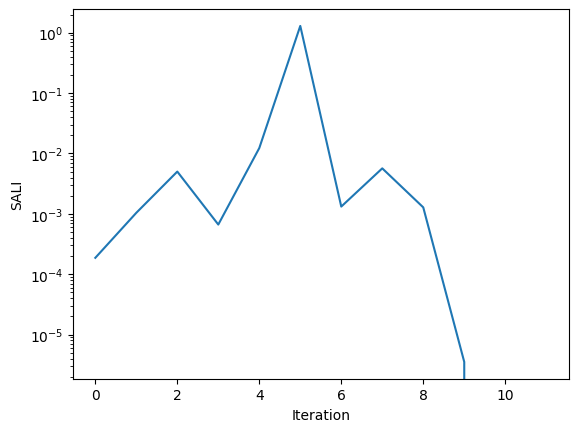

In [46]:
# Regular motion case
v0 = 2.4
t0 = 0.2
e = 0.5
N_it = 50
sali_regular = compute_sali(e, v0, t0, N_it)
plt.plot(np.arange(len(sali_regular)), sali_regular, label='Regular motion')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('SALI')
print(sali_regular)